# Movie Success Prediction - Data Visualization Notebook

This notebook performs exploratory data analysis on the cleaned TMDB movie dataset. It uses visualizations to examine patterns in movie ratings, budgets, revenues, genres, popularity, and success outcomes. These graphs help identify trends in the data before building the machine learning model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../Datasets/clean_movies.csv")

df.head()

,id,title,genres,keywords,cast,budget,revenue,runtime,vote_average,vote_count,popularity,release_date,original_language,director,release_year,success,profit,roi,main_genre,main_actor
0,19995,Avatar,"['Action', 'Adventure', 'Fantasy', 'Science Fi...","['culture clash', 'future', 'space war', 'spac...","['Sam Worthington', 'Zoe Saldana', 'Sigourney ...",237000000,2787965087,162.0,7.2,11800,150.437577,2009-12-10,en,James Cameron,2009,True,2550965087,10.763566,Action,Sam Worthington
1,285,Pirates of the Caribbean: At World's End,"['Adventure', 'Fantasy', 'Action']","['ocean', 'drug abuse', 'exotic island', 'east...","['Johnny Depp', 'Orlando Bloom', 'Keira Knight...",300000000,961000000,169.0,6.9,4500,139.082615,2007-05-19,en,Gore Verbinski,2007,True,661000000,2.203333,Adventure,Johnny Depp
2,206647,Spectre,"['Action', 'Adventure', 'Crime']","['spy', 'based on novel', 'secret agent', 'seq...","['Daniel Craig', 'Christoph Waltz', 'Léa Seydo...",245000000,880674609,148.0,6.3,4466,107.376788,2015-10-26,en,Sam Mendes,2015,True,635674609,2.594590,Action,Daniel Craig
3,49026,The Dark Knight Rises,"['Action', 'Crime', 'Drama', 'Thriller']","['dc comics', 'crime fighter', 'terrorist', 's...","['Christian Bale', 'Michael Caine', 'Gary Oldm...",250000000,1084939099,165.0,7.6,9106,112.312950,2012-07-16,en,Christopher Nolan,2012,True,834939099,3.339756,Action,Christian Bale
4,49529,John Carter,"['Action', 'Adventure', 'Science Fiction']","['based on novel', 'mars', 'medallion', 'space...","['Taylor Kitsch', 'Lynn Collins', 'Samantha Mo...",260000000,284139100,132.0,6.1,2124,43.926995,2012-03-07,en,Andrew Stanton,2012,True,24139100,0.092843,Action,Taylor Kitsch


In [2]:
df.shape

(3227, 20)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3227 entries, 0 to 3226
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3227 non-null   int64  
 1   title              3227 non-null   object 
 2   genres             3227 non-null   object 
 3   keywords           3227 non-null   object 
 4   cast               3227 non-null   object 
 5   budget             3227 non-null   int64  
 6   revenue            3227 non-null   int64  
 7   runtime            3227 non-null   float64
 8   vote_average       3227 non-null   float64
 9   vote_count         3227 non-null   int64  
 10  popularity         3227 non-null   float64
 11  release_date       3227 non-null   object 
 12  original_language  3227 non-null   object 
 13  director           3227 non-null   object 
 14  release_year       3227 non-null   int64  
 15  success            3227 non-null   bool   
 16  profit             3227 

In [4]:
df.isnull().sum()

id                   0
title                0
genres               0
keywords             0
cast                 0
budget               0
revenue              0
runtime              0
vote_average         0
vote_count           0
popularity           0
release_date         0
original_language    0
director             0
release_year         0
success              0
profit               0
roi                  0
main_genre           0
main_actor           0
dtype: int64

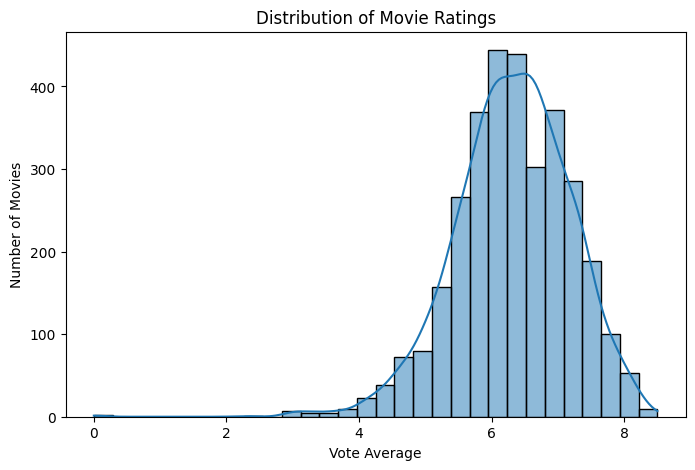

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["vote_average"], bins=30, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="budget", y="revenue", hue="success")
plt.title("Budget vs Revenue by Movie Success")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="budget", y="revenue", hue="success")
plt.xscale("log")
plt.yscale("log")
plt.title("Budget vs Revenue by Movie Success (Log Scale)")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

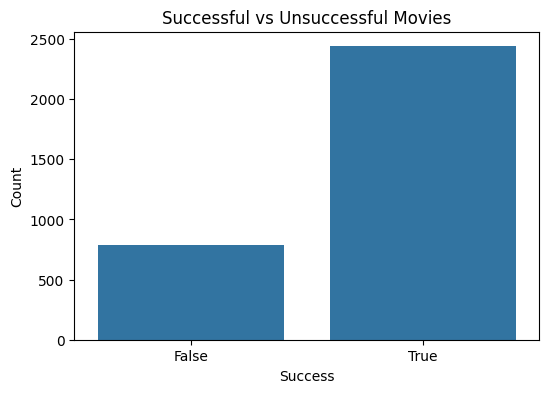

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="success")
plt.title("Successful vs Unsuccessful Movies")
plt.xlabel("Success")
plt.ylabel("Count")
plt.show()

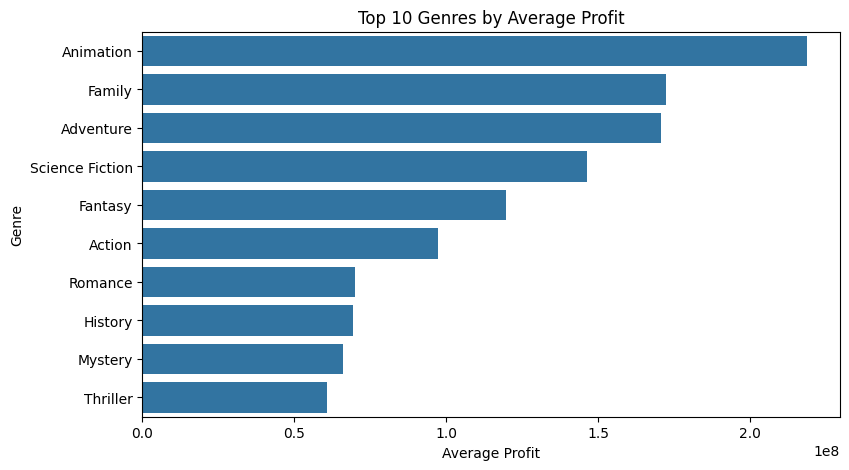

In [9]:
genre_profit = df.groupby("main_genre")["profit"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
sns.barplot(x=genre_profit.values, y=genre_profit.index)
plt.title("Top 10 Genres by Average Profit")
plt.xlabel("Average Profit")
plt.ylabel("Genre")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="popularity", y="vote_average", hue="success")
plt.title("Popularity vs Vote Average")
plt.xlabel("Popularity")
plt.ylabel("Vote Average")
plt.show()

In [ ]:
numeric_cols = [
    "budget", "revenue", "runtime", "vote_average",
    "vote_count", "popularity", "release_year", "profit", "roi"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Movie Features")
plt.show()

In [12]:
os.makedirs("../Visualization_Results", exist_ok=True)

genre_profit.to_csv("../Visualization_Results/top_genres_by_avg_profit.csv")

print("Visualization summary files saved.")

Visualization summary files saved.
